In [1]:
import numpy as np
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import pandas as pd
import pickle
np.random.seed(42)
tf.random.set_seed(42)
plt.style.use('ggplot')
import sys
import numpy

### SETUP COPULA
sys.path.append("D:/NPC")
#sys.path.append("C:/Users/alessandro/Documents/GitHub/NPC")
sys.path.append("/n/data2/hms/neurobio/harvey/Houman/NPC/NPC")

import tensorflow as tf
gpu_devices = tf.config.experimental.list_physical_devices('GPU')
#device = gpu_devices[0]
# tf.config.experimental.set_memory_growth(device, True)
import tensorflow_probability as tfp
tfd = tfp.distributions
tfb = tfp.bijectors
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
import sys
from classes.objects import *
from vine_tree.tree_op import *

from scipy import stats
import pickle

###########

from param.generate_rvine import *
from param.margin_fit import *
from param.margin_op import *
from param.copula_fit import *
from param.cond_copula import *
from pre_proc.preparation import prep_cop
from pred.prediction import*
from sampling.vine_sample import *
from info.info_estimation import vine_entropy

#gpu_available = tf.test.is_gpu_available('GPU')
#gpu_available = tf.config.list_physical_devices('GPU')
#print(gpu_available)

#print(tf.test.is_gpu_available('GPU:0'))
#tf.test.gpu_device_name()
#from tensorflow.python.client import device_lib
#print(device_lib.list_local_devices())

In [ ]:
#### Generate random matrix

cases = 3000        ### Number of samples
vine_type = 'c-vine' # or 'd-vine' or 'c-vine'
method = 'matrix'  # or 'r_matrix'  only with r-vine
binning = False
n_bin = 3
dim = 8                # Dimension of the vine for random r-vine or c-vine or d-vine


if vine_type == 'r-vine':
    
    if method == 'matrix':
        
        ######### REGULAR MATRIX
#         r_matrix = np.array([[2, 0, 0, 0, 0],
#                              [5, 3, 0, 0, 0],
#                              [4, 5, 1, 0, 0],
#                              [1, 4, 5, 4, 0],
#                              [3, 1, 4, 5, 5]])
        
#         r_matrix = np.array([[3, 0, 0, 0],
#                              [1, 4, 0, 0],
#                              [2, 1, 2, 0],
#                              [4, 2, 1, 1]])
        
#         r_matrix = np.array([[3, 0, 0],
#                              [2, 2, 0],
#                              [1, 1, 1]])

        print(r_matrix)
        
    elif method == 'random':
        
        ##### RANDOM R-MATRIX
        r_matrix, ind_vine, nodes, E = random_r_matrix_gen(dim)
        print(r_matrix)

    E, ind_vine, nodes, matrix_edges = prepare_regular(r_matrix)
    print('matrix_edges',matrix_edges)
    
    ## DEFINE MARGINS
#     margin_fam1 = ['norm','gamma','norm','gamma','norm']
#     theta_fam1 = [[0,1],[2,4],[0,1],[2,4],[0,1]]
    margin_fam1 = ['norm','norm','norm','norm','norm']
    theta_fam1 = [[0,1],[0,1],[0,1],[0,1],[0,1]]
    is_cont1 = [True,True,True,True,True]

    margin_vine = []
    for i in range(0,len(margin_fam1),1):
        mar_p = margin_obj(margin_fam1[i], theta_fam1[i], is_cont1[i])
        margin_vine.append(mar_p)

    for i in range(0,len(margin_fam1),1):
        print(margin_vine[i].dist, end =' ')
        print(margin_vine[i].theta, end =' ')
    
    ######################## DEFINE COPULAS  ###################
    if not binning:
        
#         margin_cop1 = [['gaussian','gaussian','gaussian','gaussian'],
#                        ['gaussian','gaussian','gaussian'],
#                        ['gaussian','gaussian'],
#                        ['gaussian']]
        
#         theta_cop1 = [[0.3, 0.5, 0.7, 0.8],
#                       [0.5, 0.8, 0.4],
#                       [0.5, 0.3],
#                       [0.9]]

#         margin_cop1 = [['gaussian','gaussian','gaussian','gaussian','gaussian'],
#                        ['gaussian','gaussian','gaussian','gaussian'],
#                        ['gaussian','gaussian','gaussian'],
#                        ['gaussian','gaussian'],
#                        ['gaussian']]
        
#         theta_cop1 = [[0.3, 0.5, 0.7, 0.8, -0.8],
#                       [0.5, 0.8, 0.4, -0.2],
#                       [0.5, 0.3, -0.7],
#                       [0.9, 0.6],
#                       [0.5]]
        
#         margin_cop1 = [['gaussian','student','clayton','gaussian'],
#                        ['student','clayton','gaussian'],
#                        ['student','gaussian'],
#                        ['clayton']]

#         theta_cop1 = [[0.9, [0,0.2], 0.2,  -0.8],
#                       [[-0.8,0.2], 4.5,  -0.2],
#                       [[0,0.5],  -0.7],
#                       [0.9]]
        

        margin_cop1 = [['gaussian','student','gaussian','gaussian','student','gaussian','student'],
                       ['gaussian','student','gaussian','gaussian','student','gaussian'],
                       ['gaussian','student','gaussian','gaussian','student'],
                       ['gaussian','gaussian','gaussian','gaussian'],
                       ['gaussian','gaussian','gaussian'],
                       ['gaussian','gaussian'],
                       ['gaussian']]

        theta_cop1 = [[0.9, [0,0.2], -0.9, -0.8, [0,-0.2], -0.8, [0,-0.2]],
                      [0.9, [0,0.2], -0.9, -0.8, [0,-0.2], -0.8],
                      [0.9, [0,0.2], -0.9, -0.8, [0,-0.2]],
                      [0.3, 0.7, 0.4, 0.1],
                      [0.2, -0.3, 0.1],
                      [0.2, 0.2],
                      [0.1]]
        
#         margin_cop1 = [['gaussian','gaussian','gaussian'],
#                        ['gaussian','gaussian'],
#                        ['gaussian']]

#         theta_cop1 = [[0.7, 0.8, 0.9],
#                       [0.6, 0.5],
#                       [0.7]]

    else:
        
        margin_cop1 = [['gaussian','gaussian','gaussian','gaussian'],
                       [['gaussian','gaussian','gaussian'],['gaussian','gaussian','gaussian'],['gaussian','gaussian','gaussian']],
                      [['gaussian','gaussian','gaussian'],['gaussian','gaussian','gaussian']],
                      [['gaussian','gaussian','gaussian']]]

        theta_cop1 = [[0.3, 0.5, 0.7, 0.8],
                      [[0.3, 0.4, 0.5],[0.6, 0.7, 0.8],[0.2, 0.3, 0.4]],
                      [[0.3, 0.4, 0.5],[0.3, 0.5, 0.9]],
                      [[0.2, 0.5, 0.9]]] #0.2,0.5,0.9
        
#         margin_cop1 = [['gaussian','gaussian','gaussian'],
#                        [['gaussian','gaussian','gaussian'],['gaussian','gaussian','gaussian']],
#                       [['gaussian','gaussian','gaussian']]]

#         theta_cop1 = [[0.7, 0.8, 0.9],
#                       [[0.3, 0.4, 0.5],[0.6, 0.7, 0.8]],
#                       [[0.2, 0.5, 0.9]]]

#         margin_cop1 = [['gaussian','gaussian'],
#                       [['gaussian','gaussian','gaussian']]]

#         theta_cop1 = [[0.7, 0.8],
#                       [[0.2, 0.5, 0.9]]]


    d = len(r_matrix)
    cop_vine = []
    for tr in range(0,d-1,1):
        cop_vine1 = []
        for col in range(0,d-1-tr,1):
            if (tr == 0) | (binning == False):
                cop_p = cop_par_obj(margin_cop1[tr][col],theta_cop1[tr][col])
                cop_vine1.append(cop_p)
            else:
                cop_vine11 = []
                for bb in range(0,n_bin,1):
                    cop_p = cop_par_obj(margin_cop1[tr][col][bb],theta_cop1[tr][col][bb])
                    cop_vine11.append(cop_p)
                cop_vine1.append(cop_vine11)
        cop_vine.append(cop_vine1)

    for tr in range(0,d-1,1):
        for col in range(0,d-1-tr,1):
            if (tr == 0) | (binning == False):
                print('edge: {} '.format(matrix_edges[tr][col]), 'cop family: {}'.format(cop_vine[tr][col].family), 'theta: {}'.format(cop_vine[tr][col].theta))
            else:
                for bb in range(0,n_bin,1):
                    print('edge: {} '.format(matrix_edges[tr][col]),'bin: {} '.format(bb), 'cop family: {}'.format(cop_vine[tr][col][bb].family), 'theta: {}'.format(cop_vine[tr][col][bb].theta))

    ################# IF YOU WANT TO USE C-VINE OR D-VINE    ################################### 
elif (vine_type == 'c-vine') | (vine_type == 'd-vine'):
    
    
    r_matrix, ind_vine, nodes, matrix_edges = prepare_vine(vine_type, dim)

    print(r_matrix)

    binning = False
    n_bin = 3
    
    ########## DEFINE MARGINS
    
    margin_vine = []
    for i in range(0,dim,1):
        mar_p = margin_obj('norm', [0,1], True)
        margin_vine.append(mar_p)

    for i in range(0,dim,1):
        print(margin_vine[i].dist, end =' ')
        print(margin_vine[i].theta, end =' ')

    ############## DEFINE COPULAS
    
    ## Define all the copulae by hand
#     margin_cop1 = [['gaussian','student','clayton','gaussian'],
#                    ['student','clayton','gaussian'],
#                    ['student','gaussian'],
#                    ['clayton']]
        
#     theta_cop1 = [[0.9, [0,0.2], 1.7,  -0.8],
#                   [[-0.8,0.2], 4.5,  -0.2],
#                   [[0,0.5],  -0.7],
#                   [0.9]]

        margin_cop1 = [['gaussian','student','gaussian','gaussian','student','gaussian','student'],
                       ['gaussian','student','gaussian','gaussian','student','gaussian'],
                       ['gaussian','student','gaussian','gaussian','student'],
                       ['gaussian','gaussian','gaussian','gaussian'],
                       ['gaussian','gaussian','gaussian'],
                       ['gaussian','gaussian'],
                       ['gaussian']]

        theta_cop1 = [[0.9, [0,0.2], -0.9, -0.8, [0,-0.2], -0.8, [0,-0.2]],
                      [0.9, [0,0.2], -0.9, -0.8, [0,-0.2], -0.8],
                      [0.9, [0,0.2], -0.9, -0.8, [0,-0.2]],
                      [0.3, 0.7, 0.4, 0.1],
                      [0.2, -0.3, 0.1],
                      [0.2, 0.2],
                      [0.1]]
    
    d = len(r_matrix)
    cop_vine = []
    for tr in range(0,d-1,1):
        cop_vine1 = []
        for col in range(0,d-1-tr,1):
            if (tr == 0) | (binning == False):
                cop_p = cop_par_obj(margin_cop1[tr][col],theta_cop1[tr][col])
                cop_vine1.append(cop_p)
            else:
                cop_vine11 = []
                for bb in range(0,n_bin,1):
                    cop_p = cop_par_obj(margin_cop1[tr][col][bb],theta_cop1[tr][col][bb])
                    cop_vine11.append(cop_p)
                cop_vine1.append(cop_vine11)
        cop_vine.append(cop_vine1)
    
    #### The commented code can be used to put all copulas equal to one parametric family
    # NN = 0
#     tr = 0
#     cop_vine = []
#     for i in range(dim,1,-1):
#         cop_vine1 = []
#         for j in range(0,i-1,1):
#             if (tr == 0) | (binning == False):
#     #             if tr == NN:
#     #                 cop_p = cop_par_obj('ind',[])  #
#     #                 cop_vine1.append(cop_p)
#     #             else:
#                 cop_p = cop_par_obj('gaussian',0.9)  #
#                 cop_vine1.append(cop_p)
#             else:
#                 cop_vine11 = []
#                 for bb in range(0,n_bin,1):
#                     cop_p = cop_par_obj('gaussian',0.9)
#                     cop_vine11.append(cop_p)
#                 cop_vine1.append(cop_vine11)
#         cop_vine.append(cop_vine1)
#         tr += 1

    d = len(r_matrix)
    for tr in range(0,d-1,1):
        for col in range(0,d-1-tr,1):
            if (tr == 0) | (binning == False):
                print('edge: {} '.format(matrix_edges[tr][col]), 'cop family: {}'.format(cop_vine[tr][col].family), 'theta: {}'.format(cop_vine[tr][col].theta))
            else:
                for bb in range(0,n_bin,1):
                    print('edge: {} '.format(matrix_edges[tr][col]),'bin: {} '.format(bb), 'cop family: {}'.format(cop_vine[tr][col][bb].family), 'theta: {}'.format(cop_vine[tr][col][bb].theta))


### Generate samples

sample1, v, v_flip, tau_corr, tau_bins = generate_r_samples(cases, r_matrix, ind_vine, nodes, margin_vine, cop_vine, n_bin, binning)
print(sample1)


# str1 = 'C:/Users/alessandromv/Documents/Houman/Alessandro_Houman/Dv1.mat'
# sio.savemat(str1,{'data':sample,'sample':sample})


nodes:
[1 2 3 4 5 6 7 8]
edges:
['(1,2)', '(1,3)', '(1,4)', '(1,5)', '(1,6)', '(1,7)', '(1,8)']
['(2,3|1)', '(2,4|1)', '(2,5|1)', '(2,6|1)', '(2,7|1)', '(2,8|1)']
['(3,4|2,1)', '(3,5|2,1)', '(3,6|2,1)', '(3,7|2,1)', '(3,8|2,1)']
['(4,5|3,2,1)', '(4,6|3,2,1)', '(4,7|3,2,1)', '(4,8|3,2,1)']
['(5,6|4,3,2,1)', '(5,7|4,3,2,1)', '(5,8|4,3,2,1)']
['(6,7|5,4,3,2,1)', '(6,8|5,4,3,2,1)']
['(7,8|6,5,4,3,2,1)']
[[8 0 0 0 0 0 0 0]
 [7 7 0 0 0 0 0 0]
 [6 6 6 0 0 0 0 0]
 [5 5 5 5 0 0 0 0]
 [4 4 4 4 4 0 0 0]
 [3 3 3 3 3 3 0 0]
 [2 2 2 2 2 2 2 0]
 [1 1 1 1 1 1 1 1]]
norm [0, 1] norm [0, 1] norm [0, 1] norm [0, 1] norm [0, 1] norm [0, 1] norm [0, 1] norm [0, 1] edge: (1,2)  cop family: gaussian theta: 0.9
edge: (1,3)  cop family: student theta: [0, 0.2]
edge: (1,4)  cop family: gaussian theta: -0.9
edge: (1,5)  cop family: gaussian theta: -0.8
edge: (1,6)  cop family: student theta: [0, -0.2]
edge: (1,7)  cop family: gaussian theta: -0.8
edge: (1,8)  cop family: student theta: [0, -0.2]
edge: (2,3|1)  c

2023-09-17 00:10:48.711411: I tensorflow/core/platform/cpu_feature_guard.cc:142] Your CPU supports instructions that this TensorFlow binary was not compiled to use: AVX2 AVX512F FMA
2023-09-17 00:10:48.718046: I tensorflow/core/platform/profile_utils/cpu_utils.cc:94] CPU Frequency: 3000000000 Hz
2023-09-17 00:10:48.718166: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x611d6c0 executing computations on platform Host. Devices:
2023-09-17 00:10:48.718179: I tensorflow/compiler/xla/service/service.cc:175]   StreamExecutor device (0): Host, Default Version


-----------
-----------
-----------
-----------
[[-0.31985238  0.43214414  0.62694716 ...         nan         nan
          nan]
 [ 0.25623417  0.46937504 -0.16474661 ...         nan         nan
          nan]
 [-0.5122379  -0.43394744 -0.02978915 ...         nan         nan
          nan]
 ...
 [-0.50085646  0.53657794  0.88489425 ...         nan         nan
          nan]
 [-0.86236566 -0.93680984 -0.8209766  ...         nan         nan
          nan]
 [-0.85779583  0.00444158  0.9490933  ...         nan         nan
          nan]]


In [3]:

#cases = 1000        ### Number of samples
#vine_type = 'd-vine' # or 'd-vine' or 'c-vine'
#method = 'matrix'  # or 'r_matrix'  only with r-vine
#binning = False
#n_bin = 3
#dim = 2                # Dimension of the vine for random r-vine or c-vine or d-vine


if vine_type == 'r-vine':
    
    if method == 'matrix':
        
        ######### REGULAR MATRIX
#         r_matrix = np.array([[2, 0, 0, 0, 0],
#                              [5, 3, 0, 0, 0],
#                              [4, 5, 1, 0, 0],
#                              [1, 4, 5, 4, 0],
#                              [3, 1, 4, 5, 5]])
        
#         r_matrix = np.array([[3, 0, 0, 0],
#                              [1, 4, 0, 0],
#                              [2, 1, 2, 0],
#                              [4, 2, 1, 1]])
        
#         r_matrix = np.array([[3, 0, 0],
#                              [2, 2, 0],
#                              [1, 1, 1]])

        print(r_matrix)
        
    elif method == 'random':
        
        ##### RANDOM R-MATRIX
        r_matrix, ind_vine, nodes, E = random_r_matrix_gen(dim)
        print(r_matrix)

    E, ind_vine, nodes, matrix_edges = prepare_regular(r_matrix)
    print('matrix_edges',matrix_edges)
    
    ## DEFINE MARGINS
#     margin_fam1 = ['norm','gamma','norm','gamma','norm']
#     theta_fam1 = [[0,1],[2,4],[0,1],[2,4],[0,1]]
    margin_fam1 = ['norm','norm','norm','norm','norm']
    theta_fam1 = [[0,1],[0,1],[0,1],[0,1],[0,1]]
    is_cont1 = [True,True,True,True,True]

    margin_vine = []
    for i in range(0,len(margin_fam1),1):
        mar_p = margin_obj(margin_fam1[i], theta_fam1[i], is_cont1[i])
        margin_vine.append(mar_p)

    for i in range(0,len(margin_fam1),1):
        print(margin_vine[i].dist, end =' ')
        print(margin_vine[i].theta, end =' ')
    
    ######################## DEFINE COPULAS  ###################
    if not binning:
        
#         margin_cop1 = [['gaussian','gaussian','gaussian','gaussian'],
#                        ['gaussian','gaussian','gaussian'],
#                        ['gaussian','gaussian'],
#                        ['gaussian']]
        
#         theta_cop1 = [[0.3, 0.5, 0.7, 0.8],
#                       [0.5, 0.8, 0.4],
#                       [0.5, 0.3],
#                       [0.9]]

#         margin_cop1 = [['gaussian','gaussian','gaussian','gaussian','gaussian'],
#                        ['gaussian','gaussian','gaussian','gaussian'],
#                        ['gaussian','gaussian','gaussian'],
#                        ['gaussian','gaussian'],
#                        ['gaussian']]
        
#         theta_cop1 = [[0.3, 0.5, 0.7, 0.8, -0.8],
#                       [0.5, 0.8, 0.4, -0.2],
#                       [0.5, 0.3, -0.7],
#                       [0.9, 0.6],
#                       [0.5]]
        
#         margin_cop1 = [['gaussian','student','clayton','gaussian'],
#                        ['student','clayton','gaussian'],
#                        ['student','gaussian'],
#                        ['clayton']]

#         theta_cop1 = [[0.9, [0,0.2], 0.2,  -0.8],
#                       [[-0.8,0.2], 4.5,  -0.2],
#                       [[0,0.5],  -0.7],
#                       [0.9]]
        

        margin_cop1 = [['gaussian','student','gaussian','gaussian','student','gaussian','student'],
                       ['gaussian','student','gaussian','gaussian','student','gaussian'],
                       ['gaussian','student','gaussian','gaussian','student'],
                       ['gaussian','gaussian','gaussian','gaussian'],
                       ['gaussian','gaussian','gaussian'],
                       ['gaussian','gaussian'],
                       ['gaussian']]

        theta_cop1 = [[0.9, [0,0.2], -0.9, -0.8, [0,-0.2], -0.8, [0,-0.2]],
                      [0.9, [0,0.2], -0.9, -0.8, [0,-0.2], -0.8],
                      [0.9, [0,0.2], -0.9, -0.8, [0,-0.2]],
                      [0.3, 0.7, 0.4, 0.1],
                      [0.2, -0.3, 0.1],
                      [0.2, 0.2],
                      [0.1]]
        
#         margin_cop1 = [['gaussian','gaussian','gaussian'],
#                        ['gaussian','gaussian'],
#                        ['gaussian']]

#         theta_cop1 = [[0.7, 0.8, 0.9],
#                       [0.6, 0.5],
#                       [0.7]]

    else:
        
        margin_cop1 = [['gaussian','gaussian','gaussian','gaussian'],
                       [['gaussian','gaussian','gaussian'],['gaussian','gaussian','gaussian'],['gaussian','gaussian','gaussian']],
                      [['gaussian','gaussian','gaussian'],['gaussian','gaussian','gaussian']],
                      [['gaussian','gaussian','gaussian']]]

        theta_cop1 = [[0.3, 0.5, 0.7, 0.8],
                      [[0.3, 0.4, 0.5],[0.6, 0.7, 0.8],[0.2, 0.3, 0.4]],
                      [[0.3, 0.4, 0.5],[0.3, 0.5, 0.9]],
                      [[0.2, 0.5, 0.9]]] #0.2,0.5,0.9
        
#         margin_cop1 = [['gaussian','gaussian','gaussian'],
#                        [['gaussian','gaussian','gaussian'],['gaussian','gaussian','gaussian']],
#                       [['gaussian','gaussian','gaussian']]]

#         theta_cop1 = [[0.7, 0.8, 0.9],
#                       [[0.3, 0.4, 0.5],[0.6, 0.7, 0.8]],
#                       [[0.2, 0.5, 0.9]]]

#         margin_cop1 = [['gaussian','gaussian'],
#                       [['gaussian','gaussian','gaussian']]]

#         theta_cop1 = [[0.7, 0.8],
#                       [[0.2, 0.5, 0.9]]]


    d = len(r_matrix)
    cop_vine = []
    for tr in range(0,d-1,1):
        cop_vine1 = []
        for col in range(0,d-1-tr,1):
            if (tr == 0) | (binning == False):
                cop_p = cop_par_obj(margin_cop1[tr][col],theta_cop1[tr][col])
                cop_vine1.append(cop_p)
            else:
                cop_vine11 = []
                for bb in range(0,n_bin,1):
                    cop_p = cop_par_obj(margin_cop1[tr][col][bb],theta_cop1[tr][col][bb])
                    cop_vine11.append(cop_p)
                cop_vine1.append(cop_vine11)
        cop_vine.append(cop_vine1)

    for tr in range(0,d-1,1):
        for col in range(0,d-1-tr,1):
            if (tr == 0) | (binning == False):
                print('edge: {} '.format(matrix_edges[tr][col]), 'cop family: {}'.format(cop_vine[tr][col].family), 'theta: {}'.format(cop_vine[tr][col].theta))
            else:
                for bb in range(0,n_bin,1):
                    print('edge: {} '.format(matrix_edges[tr][col]),'bin: {} '.format(bb), 'cop family: {}'.format(cop_vine[tr][col][bb].family), 'theta: {}'.format(cop_vine[tr][col][bb].theta))

    ################# IF YOU WANT TO USE C-VINE OR D-VINE    ################################### 
elif (vine_type == 'c-vine') | (vine_type == 'd-vine'):
    
    
    r_matrix, ind_vine, nodes, matrix_edges = prepare_vine(vine_type, dim)

    print(r_matrix)

    binning = False
    n_bin = 3
    
    ########## DEFINE MARGINS
    
    margin_vine = []
    for i in range(0,dim,1):
        mar_p = margin_obj('norm', [2,1], True)
        margin_vine.append(mar_p)

    for i in range(0,dim,1):
        print(margin_vine[i].dist, end =' ')
        print(margin_vine[i].theta, end =' ')

    ############## DEFINE COPULAS
    
    ## Define all the copulae by hand
#     margin_cop1 = [['gaussian','student','clayton','gaussian'],
#                    ['student','clayton','gaussian'],
#                    ['student','gaussian'],
#                    ['clayton']]
        
#     theta_cop1 = [[0.9, [0,0.2], 1.7,  -0.8],
#                   [[-0.8,0.2], 4.5,  -0.2],
#                   [[0,0.5],  -0.7],
#                   [0.9]]

        margin_cop1 = [['gaussian','student','gaussian','gaussian','student','gaussian','student'],
                       ['gaussian','student','gaussian','gaussian','student','gaussian'],
                       ['gaussian','student','gaussian','gaussian','student'],
                       ['gaussian','gaussian','gaussian','gaussian'],
                       ['gaussian','gaussian','gaussian'],
                       ['gaussian','gaussian'],
                       ['gaussian']]

        theta_cop1 = [[0.9, [0,0.2], -0.9, -0.8, [0,-0.2], -0.8, [0,-0.2]],
                      [0.9, [0,0.2], -0.9, -0.8, [0,-0.2], -0.8],
                      [0.9, [0,0.2], -0.9, -0.8, [0,-0.2]],
                      [0.3, 0.7, 0.4, 0.1],
                      [0.2, -0.3, 0.1],
                      [0.2, 0.2],
                      [0.1]]
    
    d = len(r_matrix)
    cop_vine = []
    for tr in range(0,d-1,1):
        cop_vine1 = []
        for col in range(0,d-1-tr,1):
            if (tr == 0) | (binning == False):
                cop_p = cop_par_obj(margin_cop1[tr][col],theta_cop1[tr][col])
                cop_vine1.append(cop_p)
            else:
                cop_vine11 = []
                for bb in range(0,n_bin,1):
                    cop_p = cop_par_obj(margin_cop1[tr][col][bb],theta_cop1[tr][col][bb])
                    cop_vine11.append(cop_p)
                cop_vine1.append(cop_vine11)
        cop_vine.append(cop_vine1)
    
    #### The commented code can be used to put all copulas equal to one parametric family
    # NN = 0
#     tr = 0
#     cop_vine = []
#     for i in range(dim,1,-1):
#         cop_vine1 = []
#         for j in range(0,i-1,1):
#             if (tr == 0) | (binning == False):
#     #             if tr == NN:
#     #                 cop_p = cop_par_obj('ind',[])  #
#     #                 cop_vine1.append(cop_p)
#     #             else:
#                 cop_p = cop_par_obj('gaussian',0.9)  #
#                 cop_vine1.append(cop_p)
#             else:
#                 cop_vine11 = []
#                 for bb in range(0,n_bin,1):
#                     cop_p = cop_par_obj('gaussian',0.9)
#                     cop_vine11.append(cop_p)
#                 cop_vine1.append(cop_vine11)
#         cop_vine.append(cop_vine1)
#         tr += 1

    d = len(r_matrix)
    for tr in range(0,d-1,1):
        for col in range(0,d-1-tr,1):
            if (tr == 0) | (binning == False):
                print('edge: {} '.format(matrix_edges[tr][col]), 'cop family: {}'.format(cop_vine[tr][col].family), 'theta: {}'.format(cop_vine[tr][col].theta))
            else:
                for bb in range(0,n_bin,1):
                    print('edge: {} '.format(matrix_edges[tr][col]),'bin: {} '.format(bb), 'cop family: {}'.format(cop_vine[tr][col][bb].family), 'theta: {}'.format(cop_vine[tr][col][bb].theta))


### Generate samples

sample2, v, v_flip, tau_corr, tau_bins = generate_r_samples(cases, r_matrix, ind_vine, nodes, margin_vine, cop_vine, n_bin, binning)


#sample = sample1

# sample=tf.concat([sample1,sample2],0)
sample=np.concatenate([sample1,sample2],0)

# str1 = 'C:/Users/alessandromv/Documents/Houman/Alessandro_Houman/dv1.mat'
# sio.savemat(str1,{'data':sample,'sample':sample})

nodes:
[1 2 3 4 5 6 7 8]
edges:
['(1,2)', '(1,3)', '(1,4)', '(1,5)', '(1,6)', '(1,7)', '(1,8)']
['(2,3|1)', '(2,4|1)', '(2,5|1)', '(2,6|1)', '(2,7|1)', '(2,8|1)']
['(3,4|2,1)', '(3,5|2,1)', '(3,6|2,1)', '(3,7|2,1)', '(3,8|2,1)']
['(4,5|3,2,1)', '(4,6|3,2,1)', '(4,7|3,2,1)', '(4,8|3,2,1)']
['(5,6|4,3,2,1)', '(5,7|4,3,2,1)', '(5,8|4,3,2,1)']
['(6,7|5,4,3,2,1)', '(6,8|5,4,3,2,1)']
['(7,8|6,5,4,3,2,1)']
[[8 0 0 0 0 0 0 0]
 [7 7 0 0 0 0 0 0]
 [6 6 6 0 0 0 0 0]
 [5 5 5 5 0 0 0 0]
 [4 4 4 4 4 0 0 0]
 [3 3 3 3 3 3 0 0]
 [2 2 2 2 2 2 2 0]
 [1 1 1 1 1 1 1 1]]
norm [2, 1] norm [2, 1] norm [2, 1] norm [2, 1] norm [2, 1] norm [2, 1] norm [2, 1] norm [2, 1] edge: (1,2)  cop family: gaussian theta: 0.9
edge: (1,3)  cop family: student theta: [0, 0.2]
edge: (1,4)  cop family: gaussian theta: -0.9
edge: (1,5)  cop family: gaussian theta: -0.8
edge: (1,6)  cop family: student theta: [0, -0.2]
edge: (1,7)  cop family: gaussian theta: -0.8
edge: (1,8)  cop family: student theta: [0, -0.2]
edge: (2,3|1)  c

In [4]:
dim = 8
vine_depth = dim

mean = [0, 0, 0, 0, 0, 0, 0, 0]
f=0.2
cov = [[1, f, f, f, f, f, f, f], [f, 1, f, f, f, f, f, f], [f, f, 1, f, f, f, f, f], [f, f, f, 1, f, f, f, f], [f, f, f, f, 1, f, f, f], [f, f, f, f, f, 1, f, f], [f, f, f, f, f, f, 1, f], [f, f, f, f, f, f, f, 1]]  # diagonal covariance
#mean = [0, 0, 0]
#f=0.5
#cov = [[1, f, f], [f, 1, f], [f, f, 1]]  # diagonal covariance

#mean = [0, 0]
#f=0.95
#cov = [[1, f],[f, 1]]  # diagonal covariance
#dim=2

import matplotlib.pyplot as plt
x = np.random.multivariate_normal(mean, cov, 2000).T
sample = numpy.transpose(x)
#plt.plot(sample[:,0],sample[:,1],'b.')





In [5]:
#### LOAD DATA OR VINE BANDWIDTH AND MATRIX IF NEEDED
load_mat = False
load_pickle = False

if load_mat:
    mat_contents = sio.loadmat('stu_ex_01.mat') #sim_vine #sim17_10000.mat')   #X_sim17.mat')
    # print(mat_contents)
    dat = mat_contents.get('x') #X_sim17
    dat = np.array(dat,np.float64)

    pdf_cop = mat_contents.get('pdf_cop') #X_sim17
    pdf_cop = np.array(pdf_cop,np.float32)
    
elif load_pickle:
    pickle_in = open("dict_pickle","rb")
    dict_save = pickle.load(pickle_in)
    vine = dict_save["vine"]
    sample = dict_save["data"]
    vine_depth = 20

In [6]:
################### DEFINE VINE #################

vine_type = "c-vine"#"r-vine"
method = 'optimal'#'optimal' #'matrix' #'matrix' 
families = "kercop"
knots = 100

vine_depth = len(r_matrix)

# vine_depth = 20 #len(r_matrix)

margin_vine = []
for i in range(0,vine_depth,1):
    mar_p = margin_obj('norm', [0,1], True)
    margin_vine.append(mar_p)
    
vine = vine_obj_bin(vine_type, families, vine_depth, margin_vine, knots, method, r_matrix)

nodes:
[1 2 3 4 5 6 7 8]
edges:
['(1,2)', '(1,3)', '(1,4)', '(1,5)', '(1,6)', '(1,7)', '(1,8)']
['(2,3|1)', '(2,4|1)', '(2,5|1)', '(2,6|1)', '(2,7|1)', '(2,8|1)']
['(3,4|2,1)', '(3,5|2,1)', '(3,6|2,1)', '(3,7|2,1)', '(3,8|2,1)']
['(4,5|3,2,1)', '(4,6|3,2,1)', '(4,7|3,2,1)', '(4,8|3,2,1)']
['(5,6|4,3,2,1)', '(5,7|4,3,2,1)', '(5,8|4,3,2,1)']
['(6,7|5,4,3,2,1)', '(6,8|5,4,3,2,1)']
['(7,8|6,5,4,3,2,1)']


### Vine fitting

General parameters:
- parallel: True or False           (Fit in parallel each level)
- binning: True or False            (It can be True only if parallel is False)
- param: True or False              (Parametric or Non-parametric)
- vine_depth: any                   (Max level of vine to fit)

Parametric parameters:
- param_families: ["ind","gaussian","student","clayton","claytonrot90"]   (Decide which parametric families to fit)

Non-parametric parameters:
- opt_method: 'LL1' or 'LL2'

Binning parameters:
- n_bin: any                        (Number of bins)

In [7]:
param = False
binning = False
n_bin = 3

## Make data divisible for bins and k-fold
# x = dat # sample  #dat
x = sample #[:,ind1]
#x = np.array(x,np.float32)


if binning == True:
    if param == False:
        exc = tf.math.floormod(tf.shape(x)[0],n_bin*5)
    else:
        exc = tf.math.floormod(tf.shape(x)[0],n_bin)
    x = x[:tf.shape(x)[0]-exc,:]
else:
    if param == False:
        exc = tf.math.floormod(tf.shape(x)[0],5)
        x = x[:tf.shape(x)[0]-exc,:]

## Prepare copula

sort_n = 'rand'
e = prep_cop(x, vine, sort_n)
print(e)
print(vine)

[[ 1.24774607 -1.07580556 -0.73150952 ... -0.55985264  0.84911481
   1.26678307]
 [-1.48752046 -0.80464181  0.19113593 ... -0.46354518 -1.12754894
   0.9270791 ]
 [ 1.06983815  0.41904312 -0.28190235 ...  1.43547755  0.30985421
   1.1692086 ]
 ...
 [ 1.08477273  1.27546879  0.0255847  ...  1.01932427 -0.42168145
  -0.06714201]
 [-0.36548891  0.76812987  0.20311855 ... -1.80905349  0.59873065
   0.68604839]
 [ 0.0606225   0.67383158 -0.16241643 ...  0.03273799 -0.68571649
   0.25634668]]


In [8]:
#str1 = 'D:/NPC/HS_test_vine.mat'
#sio.savemat(str1,{'data':x,'sample':sample})
#print(x)

In [9]:
### FITTING
# Parameters:
# - Data: x
# - Parallel: True or False
# - Bandwidth optimization: LL1 or LL2
# - Binning: True or false.    It can be True only if parallel is false
# - n_bin: Select the number of bins
# parallel = False

gen_dict = {'parallel':True, 'binning':binning, 'param':param, 'vine_depth':vine_depth+1, 'fitted':False}  #vine_depth
par_dict = {'param_families':["ind","gaussian"]}  #["ind","gaussian","student","clayton","claytonrot90"]
npc_dict = {'opt_method':'LL1','batch_paral':3}
bin_dict = {'n_bin':n_bin}

vine.fit(x,gen_dict,npc_dict,par_dict,bin_dict)

True
Instructions for updating:
This op will be removed after the deprecation date. Please switch to tf.sets.difference().
time_fit: 275.2264315513894
time_fit: 188.9290276914835


In [ ]:
dir(vine)
print(vine)

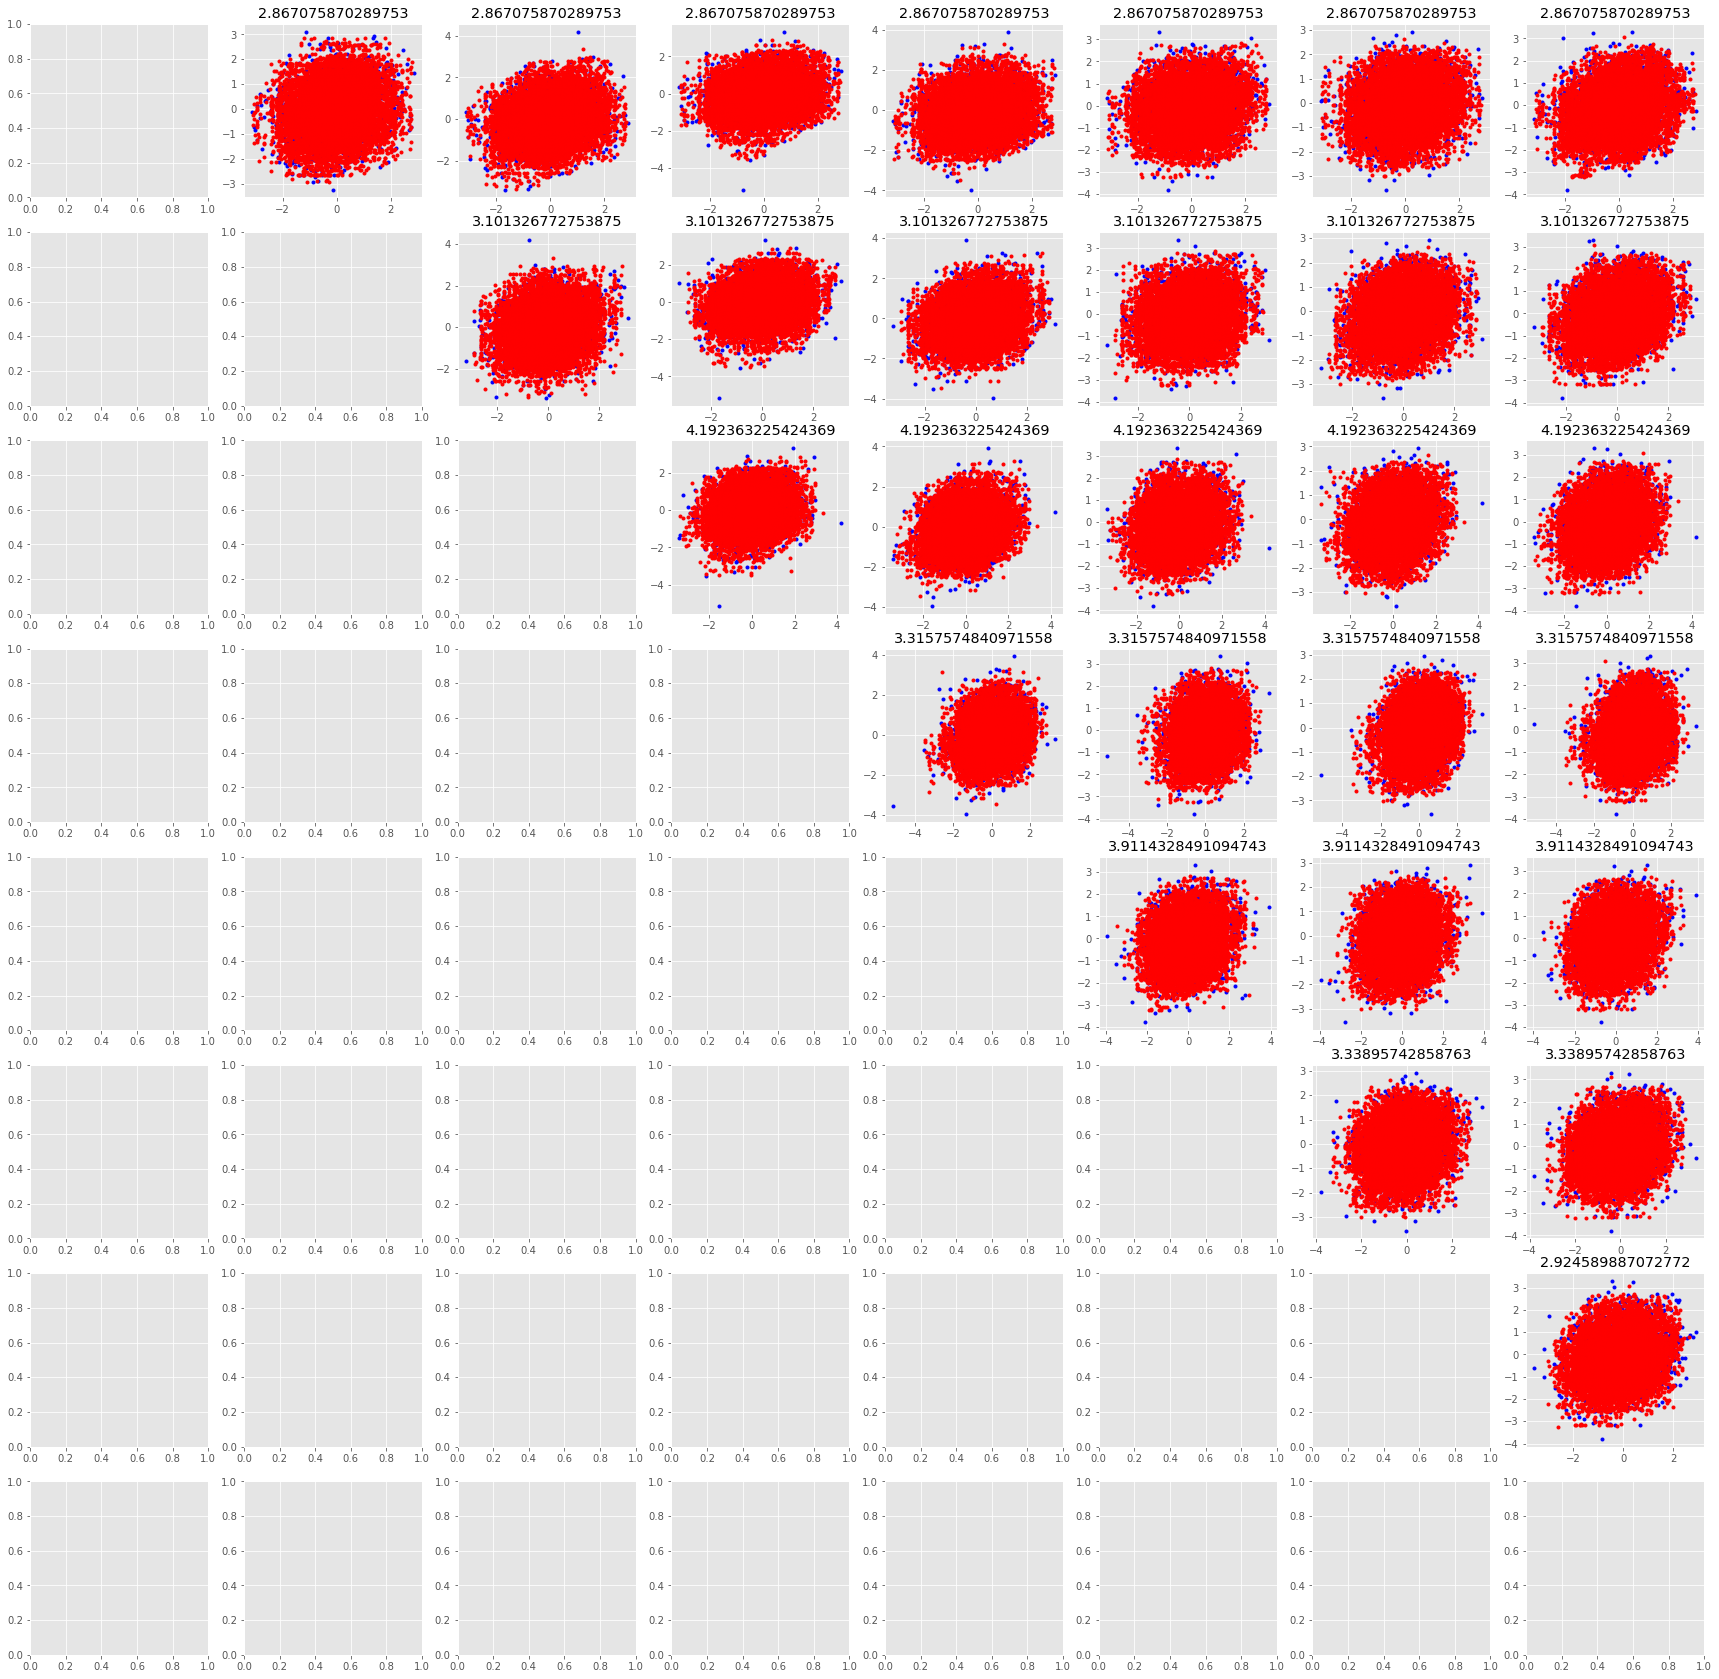

In [ ]:
sample3 ,u, pd, sd = vine_copula_sample(vine,10000)
#sample3 = pd
xx = x
#xx = u

fig, axs = plt.subplots(vine_depth, vine_depth,figsize=(30,30))
for i in range(0,vine_depth,1):
    for j in range(i+1,vine_depth,1):
        axs[i,j].plot(xx[:,i],xx[:,j],'b.')    
        axs[i,j].plot(sample3[:,i],sample3[:,j],'r.')    
        axs[i,j].set_title(str(max(xx[:,i])))
        
# fig.savefig('dv1.eps', bbox_inches='tight', dpi=150)

[-3.23721163 -2.92795918 -2.89498767 ...  2.8559642   2.94448885
  3.10132677]


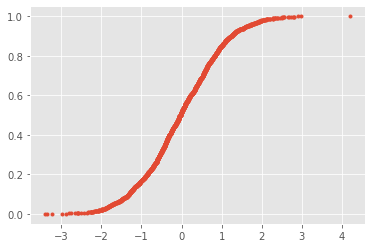

In [ ]:
plt.figure()
plt.plot(sd[:,2],pd[:,2],'.')
print(sd[:,1])

#### Vine evaluation

In [ ]:
########### CREATE POINTS FOR EVALUATION
exp_dim = 1
dim = 1
#points = create_points(x,dim,exp_dim)
#print(points)
#p, p_cop, logp = vine.evaluation(points)
p, p_cop, logp = vine.evaluation(x)

#r = vine.evaluation(x)
#mm = margin_obj(x, dist, theta, is_cont)

#### Predict response

In [ ]:
############### PREDICT VINE ##################
dim = 0
exp_dim = 100

p, y_ml, y_em = predict_vine(x,vine,dim,exp_dim)

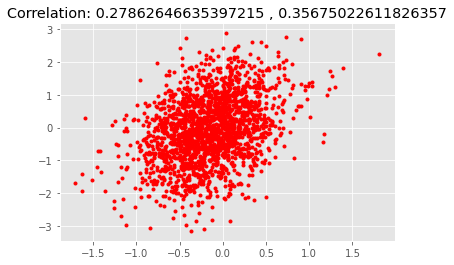

In [ ]:
from scipy import stats
corr = stats.pearsonr(x[:,dim], y_ml)
corre = stats.pearsonr(x[:,dim], y_em)

plt.figure()
#plt.plot(y_ml, x[:,dim], 'g.')
plt.plot(y_em, x[:,dim], 'r.')
plt.title('Correlation: ' + str(corr[0]) + ' , ' + str(corre[0]))
plt.show()

In [ ]:
def vine_entropy(vine,info_dict):
    alpha = info_dict['alpha']
    cases = info_dict['cases'] #number of samples in each iteration 
    max_iter = info_dict['iterations']
    d = vine.n_cop

    norm_dis = tfd.Normal(loc=0., scale=1.) 
    conf = norm_dis.quantile(1-alpha)
    tim = 0  #Add as parameter if you want to change it

    mo = 0 
    varsum1 = 0 
    infoc1 = 0
    cond_entr = 0
    entr_f2 = 0
    entr_f3 = 0
    stderr1 = 1e+6
    stderr2 = 1e+6 
    stderr3 = 1e+6 
    stderr_tot = 1e+6
    erreps = 1e-3
    
    MI_XY=numpy.zeros(max_iter,numpy.float)
    MI_SING=numpy.zeros(max_iter,numpy.float)
    EN_XY=numpy.zeros(max_iter,numpy.float)
    EN_X1=numpy.zeros(max_iter,numpy.float)
    EN_X2=numpy.zeros(max_iter,numpy.float)

    while ((stderr1 >= erreps)  | (stderr_tot >= erreps) ) & (mo < max_iter):
        mo = mo+1
        if vine.param == False:

            sample , u, p1, p2 = vine_copula_sample(vine,cases)
            #sample = x

            #x = np.random.multivariate_normal(mean, cov, 2000).T
            #sample = numpy.transpose(x)

            p, p_copula, log_marg_f= vine.evaluation(sample)

            ## Compute cond entr.
            p_cond = np.exp(np.log(p_copula.numpy()))
            #- np.log(p_f2.numpy()))
            
            log2_cond = np.log(p_cond)
            log2_cond[p_cond == 0] = 0 

            cond_12=np.mean(log2_cond);
            cond_entr = cond_entr + ( np.mean(log2_cond) - cond_entr) / mo  #tf.math.reduce_mean

            varsum1 = varsum1 + np.sum((log2_cond - cond_entr)**2)
            stderr1 = conf * np.sqrt(varsum1 / (mo * cases * (mo * cases - 1)))
            
            print(cond_entr)
            
            EN_XY[mo-1] = cond_entr
        else:
            sample = vine_cop_par_sample(vine,cases)

            # Compute pdf of samples
            p, pcop = vine.evaluation(sample)
            
            log2pp = np.log2(pcop.numpy())
            log2pp[pcop == 0] = 0 

            infoc1 = infoc1 + ( np.mean(log2pp) - infoc1) / mo
            varsum1 = varsum1 + np.sum((log2pp - infoc1)**2)
            stderr1 = conf * np.sqrt(varsum1 / (mo * cases * (mo * cases - 1)))
    
    return EN_XY

#### Vine entropy estimation

0.5143185476841031
0.5127838288293736
0.5095168753164047
0.5101340621398844
0.5083447110624619
0.5086595550647571
0.510688646319533
0.5110772484683167
0.5105595877574477
0.5108178894882556
0.5125238851728184
0.5131733078176055
0.5141940807381128
0.5136215825102809
0.5143876208986349
0.5135875152538775
0.513368491073456
0.5133326866045729
0.5131056529805952
0.5139721945796416


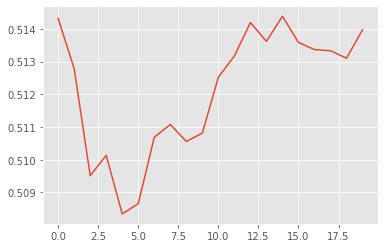

In [ ]:
#info_dict = {'cases':2000, 'iterations':10, 'alpha': 0.05}
#MI = vine_entropy(vine,info_dict)
info_dict = {'cases':10000, 'iterations':20, 'alpha': 0.05}
EN_XY = vine_entropy(vine,info_dict)
plt.plot(EN_XY)

In [ ]:
import math

analytic_entropy = -0.5 * np.log(np.linalg.det(cov))+dim/2*(1+np.log(2*math.pi))
analytic_entropyP = -0.5 * np.log(1-f**2)


print(analytic_entropy,analytic_entropyP)

0.3432680609227842 0.020410997260127583


In [ ]:
print(vine.r_matrix)
print(vine.ind_vine)

[[8 0 0 0 0 0 0 0]
 [7 7 0 0 0 0 0 0]
 [6 6 6 0 0 0 0 0]
 [5 5 5 5 0 0 0 0]
 [4 4 4 4 4 0 0 0]
 [3 3 3 3 3 3 0 0]
 [2 2 2 2 2 2 2 0]
 [1 1 1 1 1 1 1 1]]
[[[0, 1], [0, 2], [0, 3], [0, 4], [0, 5], [0, 6], [0, 7]], [[0, 1], [0, 2], [0, 3], [0, 4], [0, 5], [0, 6]], [[0, 1], [0, 2], [0, 3], [0, 4], [0, 5]], [[0, 1], [0, 2], [0, 3], [0, 4]], [[0, 1], [0, 2], [0, 3]], [[0, 1], [0, 2]], [[0, 1]]]
